# CuttleFish Notebook Workflow

This notebook is the primary interactive entrypoint. All plotting code is written inline in each cell so figure details can be edited directly without going through rendering helpers.


In [1]:
# %% Cell 1: Imports and paths
import math
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.colors import BoundaryNorm, ListedColormap

from CuttleFishModel.core import PARAMS, BLACK, RED, SKIN, YELLOW, pigment_display_size, simulate
from CuttleFishModel.metrics import (
    nearest_neighbor_distances,
    pair_correlation_like,
    pigment_points,
    summarize_nnd,
    timeline_to_dataframe,
)
from CuttleFishModel.controls import (
    MODE_COLORS,
    MODE_LABELS,
    run_ablation,
    run_random_development_matched,
    run_random_mask,
    scan_parameter_landscape,
    summarize_result,
)

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
REPORT_DIR = RESULTS_DIR
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT, REPORT_DIR


(PosixPath('/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj'),
 PosixPath('/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results'))

In [2]:
# %% Cell 2: Parameters
params = PARAMS.copy()

# Editable key parameters
params["yellow_duration"] = 28
params["red_duration"] = 3
params["absolute_min_distance"] = 2.6
params["target_gap_to_black"] = 5.0
params["growth_motion_strength"] = 1.0
params["base_birth_rate"] = 0.82
params["n_steps"] = 170
params["seed"] = 7

params


{'seed': 7,
 'grid_size': 100,
 'n_steps': 170,
 'initial_radius_x': 8.0,
 'initial_radius_y': 6.5,
 'initial_pigments': 4,
 'growth_rate': 0.94,
 'growth_power': 0.95,
 'growth_curve_exponent': 1.35,
 'radial_growth_softness': 1.2,
 'radial_growth_margin': 0.9,
 'late_growth_floor': 0.24,
 'final_growth_radius': 49.0,
 'min_skin_age_for_diff': 2,
 'candidate_sample_size': 2400,
 'base_birth_rate': 0.82,
 'birth_prob_cap': 0.78,
 'max_new_pigments_per_step': 10,
 'birth_quota_base': 1.0,
 'birth_quota_skin_scale': 0.0011,
 'birth_quota_deficit_scale': 0.08,
 'target_area_per_pigment': 28.0,
 'absolute_min_distance': 2.6,
 'all_spacing_softness': 0.9,
 'field_threshold': 0.92,
 'field_softness': 0.18,
 'target_gap_to_black': 5.0,
 'target_gap_sigma': 1.6,
 'bootstrap_gap_to_all': 5.5,
 'bootstrap_black_count': 18,
 'black_gap_weight': 1.55,
 'fallback_gap_weight': 1.15,
 'min_boundary_distance': 3.2,
 'boundary_softness': 0.9,
 'center_birth_floor': 0.28,
 'center_birth_sigma_fraction':

In [3]:
# %% Cell 3: Run self-organized model
timeline, final_step = simulate(params)
final_frame = timeline[final_step]
comparison_step = final_step
comparison_steps = [step for step in [0, 40, 80, 120, comparison_step] if step <= comparison_step]

print(f"final_step = {final_step}")
print(f"pigment_count = {final_frame.pigment_count}")
print(f"yellow / red / black = {final_frame.yellow_count} / {final_frame.red_count} / {final_frame.black_count}")
print(f"CV_NND = {final_frame.nnd_cv:.6f}")

final_frame


final_step = 141
pigment_count = 185
yellow / red / black = 55 / 2 / 128
CV_NND = 0.169153


Frame(step=141, skin=array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(100, 100), dtype=int8), pigments=[Pigment(pos=array([68.57483688, 19.52525633]), age=147, base_major=2.4712335948383783, base_minor=2.0194882819723357, angle=123.59578130448094, tone=-0.039386384718706646), Pigment(pos=array([51.88384124, 85.25761856]), age=147, base_major=2.7597695780901286, base_minor=1.9476789820217701, angle=29.99290165180292, tone=-0.07648559448990577), Pigment(pos=array([83.87538167, 65.12517349]), age=145, base_major=1.886908397215659, base_minor=1.3738014350013825, angle=3.5503608072816273, tone=0.028568126829716347), Pigment(pos=array([21.37468772, 65.12517349]), age=148, base_major=2.8282420585989043, base_minor=2.3547504756327644, angle=76.80952129651365, tone=0.04424584850166807), Pigment(pos=array([46.63775019, 23.73975171]), a

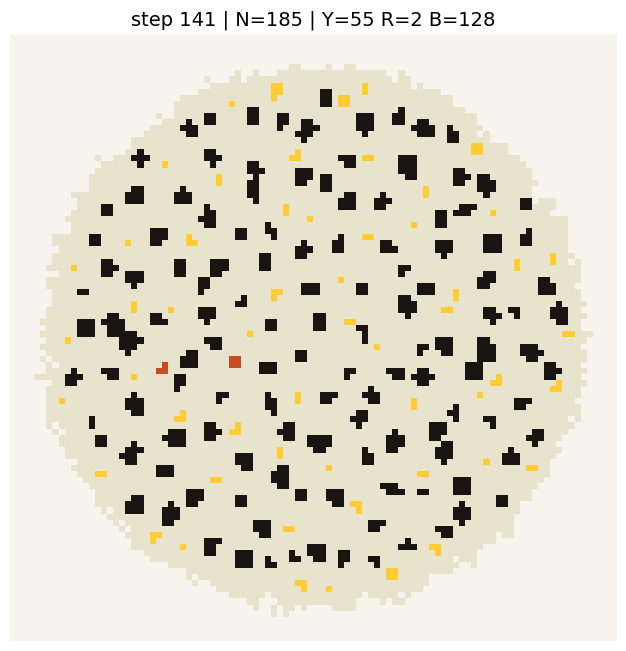

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/final_frame_preview.png


In [4]:
# %% Cell 4: Preview final frame
figsize = (6.4, 6.4)
dpi = 220
preview_title = (
    f"step {final_step} | N={final_frame.pigment_count} | "
    f"Y={final_frame.yellow_count} R={final_frame.red_count} B={final_frame.black_count}"
)
preview_path = REPORT_DIR / "final_frame_preview.png"

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)

state_grid = final_frame.skin.copy()
score_grid = np.full(final_frame.skin.shape, -np.inf, dtype=float)
priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}

grid_size = final_frame.skin.shape[0]
for pigment in final_frame.pigments:
    stage = pigment.stage(params)
    major, minor = pigment_display_size(pigment, params)
    half_h = max(1, int(math.ceil(major * 0.75)))
    half_w = max(1, int(math.ceil(major * 0.75)))
    rr_center = pigment.pos[0]
    cc_center = pigment.pos[1]
    angle = math.radians(pigment.angle)
    cos_a = math.cos(angle)
    sin_a = math.sin(angle)

    rows = []
    cols = []
    for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
        if rr < 0 or rr >= grid_size:
            continue
        for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
            if cc < 0 or cc >= grid_size:
                continue
            dy = rr - rr_center
            dx = cc - cc_center
            x_rot = cos_a * dx + sin_a * dy
            y_rot = -sin_a * dx + cos_a * dy
            value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
            if value <= 1.0:
                rows.append(rr)
                cols.append(cc)

    if not rows:
        rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
        cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]

    rows = np.asarray(rows, dtype=int)
    cols = np.asarray(cols, dtype=int)
    dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
    local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age

    for rr, cc, score in zip(rows, cols, local_score):
        if final_frame.skin[rr, cc] != SKIN:
            continue
        if score > score_grid[rr, cc]:
            state_grid[rr, cc] = stage
            score_grid[rr, cc] = score

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(preview_title, pad=7)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.savefig(preview_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(preview_path)


In [5]:
# %% Optional: Save GIF if needed
frame_stride = params["frame_stride"]
gif_duration_ms = params["gif_duration_ms"]
gif_path = RESULTS_DIR / "01_intercalated_development.gif"

frame_steps = list(range(0, final_step + 1, frame_stride))
if frame_steps[-1] != final_step:
    frame_steps.append(final_step)

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)

with TemporaryDirectory() as tmp_dir_name:
    tmp_dir = Path(tmp_dir_name)
    frame_paths = []
    for step in frame_steps:
        frame = timeline[step]
        state_grid = frame.skin.copy()
        score_grid = np.full(frame.skin.shape, -np.inf, dtype=float)
        priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}
        grid_size = frame.skin.shape[0]

        for pigment in frame.pigments:
            stage = pigment.stage(params)
            major, minor = pigment_display_size(pigment, params)
            half_h = max(1, int(math.ceil(major * 0.75)))
            half_w = max(1, int(math.ceil(major * 0.75)))
            rr_center = pigment.pos[0]
            cc_center = pigment.pos[1]
            angle = math.radians(pigment.angle)
            cos_a = math.cos(angle)
            sin_a = math.sin(angle)
            rows = []
            cols = []
            for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
                if rr < 0 or rr >= grid_size:
                    continue
                for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
                    if cc < 0 or cc >= grid_size:
                        continue
                    dy = rr - rr_center
                    dx = cc - cc_center
                    x_rot = cos_a * dx + sin_a * dy
                    y_rot = -sin_a * dx + cos_a * dy
                    value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
                    if value <= 1.0:
                        rows.append(rr)
                        cols.append(cc)
            if not rows:
                rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
                cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]
            rows = np.asarray(rows, dtype=int)
            cols = np.asarray(cols, dtype=int)
            dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
            local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age
            for rr, cc, score in zip(rows, cols, local_score):
                if frame.skin[rr, cc] != SKIN:
                    continue
                if score > score_grid[rr, cc]:
                    state_grid[rr, cc] = stage
                    score_grid[rr, cc] = score

        fig, ax = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
        ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(
            f"step {frame.step} | skin={frame.skin_area} | pigments={frame.pigment_count} | "
            f"Y={frame.yellow_count} R={frame.red_count} B={frame.black_count}",
            pad=7,
        )
        for spine in ax.spines.values():
            spine.set_visible(False)
        frame_path = tmp_dir / f"frame_{step:04d}.png"
        fig.savefig(frame_path, dpi=180)
        plt.close(fig)
        frame_paths.append(frame_path)

    images = []
    for frame_path in frame_paths:
        with Image.open(frame_path) as img:
            images.append(img.convert("P", palette=Image.ADAPTIVE))
    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=gif_duration_ms,
        loop=0,
        disposal=2,
    )

print(gif_path)


/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/01_intercalated_development.gif


In [6]:
# %% Cell 5: Run matched controls
self_summary = summarize_result({
    "mode": "self",
    "seed": params["seed"],
    "final_frame": final_frame,
    "birth_rate_scale": 1.0,
    "switches": {
        "use_repulsion": True,
        "use_gap_birth": True,
        "use_growth_displacement": True,
    },
})

random_dev_result = run_random_development_matched(
    params,
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)
random_mask_result = run_random_mask(final_frame, target_N=final_frame.pigment_count, seed=params["seed"] + 400)

random_dev_summary = summarize_result(random_dev_result)
random_mask_summary = summarize_result(random_mask_result)
summary_df = pd.DataFrame([self_summary, random_dev_summary, random_mask_summary])

print(summary_df[["model", "N", "CV_NND", "yellow_count", "red_count", "black_count"]])
print(f"random-development birth_rate_scale = {random_dev_result['birth_rate_scale']:.6f}")

summary_df


                        model    N    CV_NND  yellow_count  red_count  \
0                        self  185  0.169153            55          2   
1  random_development_matched  188  0.625262            51          6   
2                 random_mask  185  0.493751            55          2   

   black_count  
0          128  
1          131  
2          128  
random-development birth_rate_scale = 0.002000


,model,seed,N,mean_NND,std_NND,CV_NND,yellow_count,red_count,black_count,yellow_fraction,red_fraction,black_fraction,use_repulsion,use_gap_birth,use_growth_displacement,calibrated_birth_rate
0,self,7,185,4.317550,0.730327,0.169153,55,2,128,0.297297,0.010811,0.691892,True,True,True,1.000
1,random_development_matched,7,188,2.623428,1.640331,0.625262,51,6,131,0.271277,0.031915,0.696809,False,False,True,0.002
2,random_mask,407,185,3.156232,1.558393,0.493751,55,2,128,0.297297,0.010811,0.691892,False,False,False,NaN


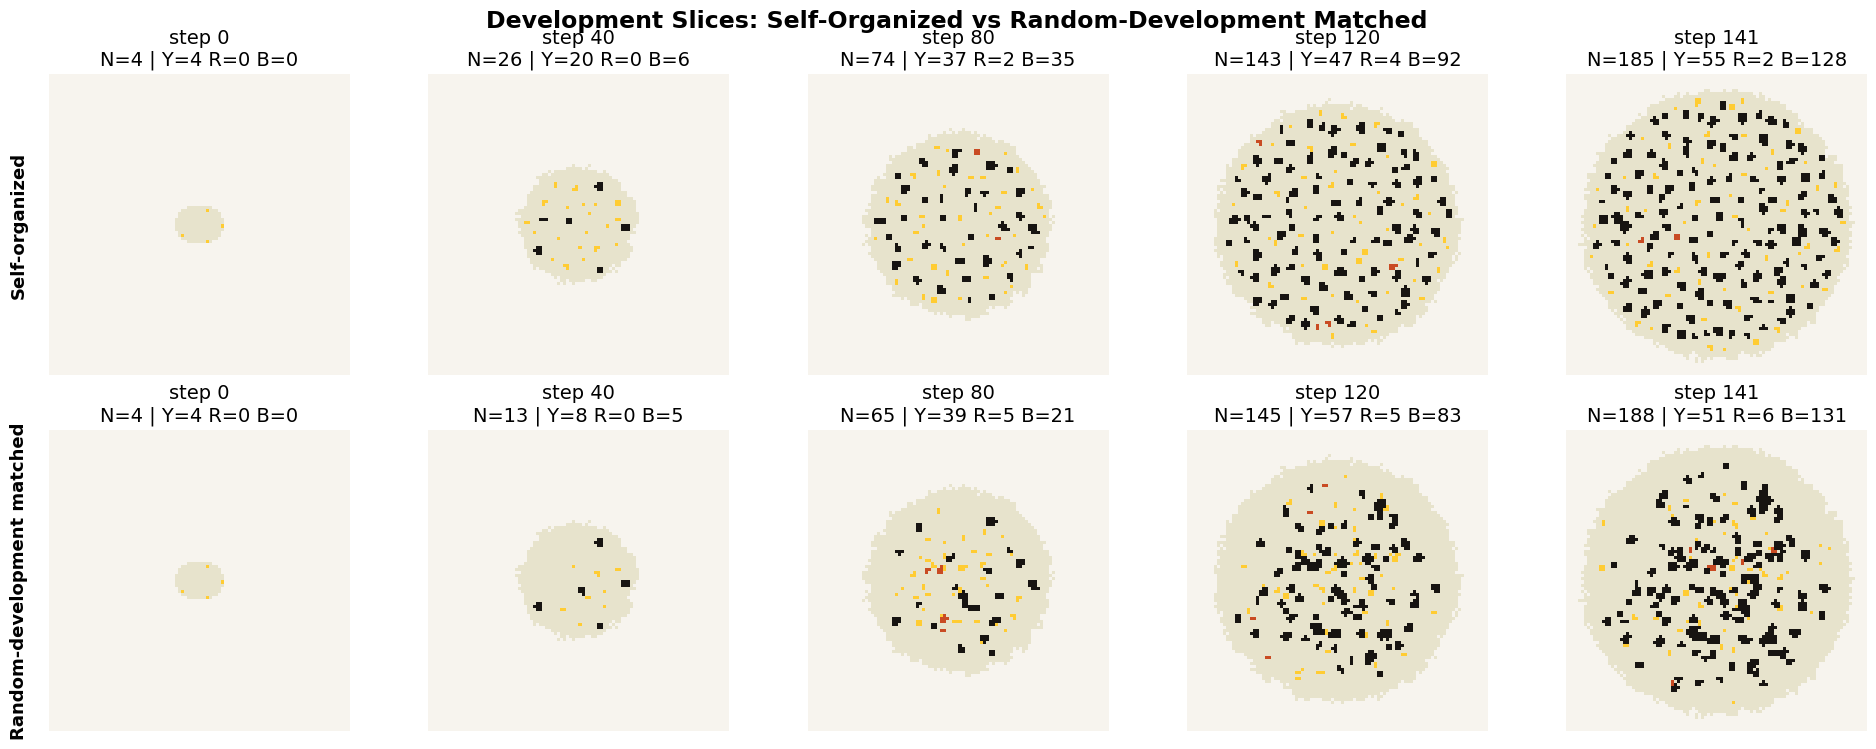

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig1_development_slices_self_vs_random.png


In [11]:
# %% Cell 6: Fig1 development slices
fig1_path = REPORT_DIR / "Fig1_development_slices_self_vs_random.png"
figsize = (19.0, 7.2)
dpi = 220

fig_steps = comparison_steps.copy()
while len(fig_steps) < 5:
    fig_steps.append(min(comparison_step, fig_steps[-1] + 1 if fig_steps else 0))
fig_steps = fig_steps[:5]
self_steps = fig_steps
random_steps = fig_steps

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)
priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}

fig, axes = plt.subplots(2, 5, figsize=figsize, constrained_layout=True)
for row_idx, (row_label, row_timeline, row_steps) in enumerate([
    ("Self-organized", timeline, self_steps),
    ("Random-development matched", random_dev_result["timeline"], random_steps),
]):
    for col_idx, step in enumerate(row_steps):
        frame = row_timeline[step]
        state_grid = frame.skin.copy()
        score_grid = np.full(frame.skin.shape, -np.inf, dtype=float)
        grid_size = frame.skin.shape[0]
        for pigment in frame.pigments:
            stage = pigment.stage(params)
            major, minor = pigment_display_size(pigment, params)
            half_h = max(1, int(math.ceil(major * 0.75)))
            half_w = max(1, int(math.ceil(major * 0.75)))
            rr_center = pigment.pos[0]
            cc_center = pigment.pos[1]
            angle = math.radians(pigment.angle)
            cos_a = math.cos(angle)
            sin_a = math.sin(angle)
            rows = []
            cols = []
            for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
                if rr < 0 or rr >= grid_size:
                    continue
                for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
                    if cc < 0 or cc >= grid_size:
                        continue
                    dy = rr - rr_center
                    dx = cc - cc_center
                    x_rot = cos_a * dx + sin_a * dy
                    y_rot = -sin_a * dx + cos_a * dy
                    value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
                    if value <= 1.0:
                        rows.append(rr)
                        cols.append(cc)
            if not rows:
                rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
                cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]
            rows = np.asarray(rows, dtype=int)
            cols = np.asarray(cols, dtype=int)
            dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
            local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age
            for rr, cc, score in zip(rows, cols, local_score):
                if frame.skin[rr, cc] != SKIN:
                    continue
                if score > score_grid[rr, cc]:
                    state_grid[rr, cc] = stage
                    score_grid[rr, cc] = score
        ax = axes[row_idx, col_idx]
        ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(
            f"step {step}\nN={frame.pigment_count} | Y={frame.yellow_count} R={frame.red_count} B={frame.black_count}",
            pad=7,
        )
        for spine in ax.spines.values():
            spine.set_visible(False)
        if col_idx == 0:
            ax.text(-0.10, 0.5, row_label, transform=ax.transAxes, rotation=90, va="center", ha="center", fontsize=13, fontweight="bold")

fig.suptitle("Development Slices: Self-Organized vs Random-Development Matched", y=1.02, fontsize=17, fontweight="bold")
fig.savefig(fig1_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig1_path)


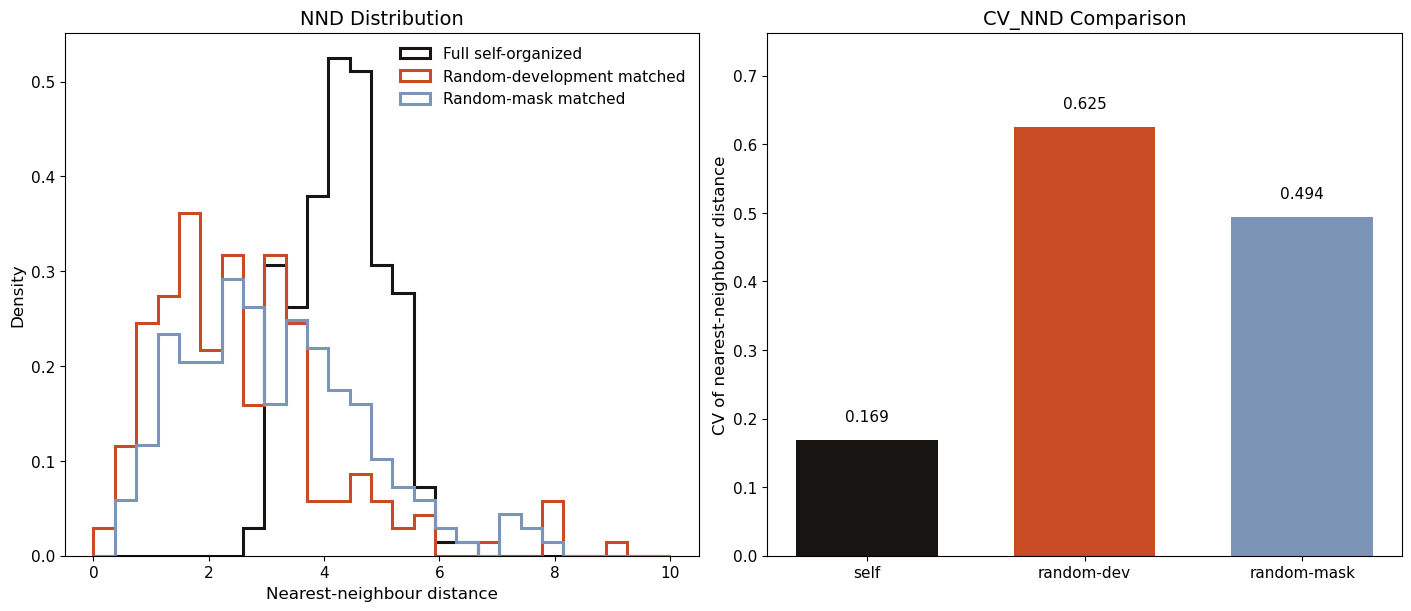

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig2_nnd_distribution_and_cv.png
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/random_vs_self_summary.csv


In [19]:
# %% Cell 7: Fig2 NND distribution and CV
fig2_path = REPORT_DIR / "Fig2_nnd_distribution_and_cv.png"
summary_csv_path = REPORT_DIR / "random_vs_self_summary.csv"
figsize = (14, 6)
dpi = 220

summary_df.to_csv(summary_csv_path, index=False)

nnd_map = {
    "self": nearest_neighbor_distances(pigment_points(final_frame)),
    "random_development_matched": nearest_neighbor_distances(pigment_points(random_dev_result["final_frame"])),
    "random_mask": nearest_neighbor_distances(pigment_points(random_mask_result["final_frame"])),
}
labels = {
    "self": MODE_LABELS["self"],
    "random_development_matched": MODE_LABELS["random_development_matched"],
    "random_mask": MODE_LABELS["random_mask"],
}
colors = {
    "self": MODE_COLORS["self"],
    "random_development_matched": MODE_COLORS["random_development_matched"],
    "random_mask": MODE_COLORS["random_mask"],
}
bins = np.linspace(0.0, 10.0, 28)
bar_order = ["self", "random_development_matched", "random_mask"]
bar_labels = ["self", "random-dev", "random-mask"]
bar_colors = [colors[key] for key in bar_order]

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
for model, values in nnd_map.items():
    axes[0].hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.2,
        color=colors[model],
        label=labels[model],
    )
axes[0].set_xlabel("Nearest-neighbour distance")
axes[0].set_ylabel("Density")
axes[0].set_title("NND Distribution")
axes[0].legend(frameon=False, loc="upper right")

cv_values = summary_df.set_index("model").loc[bar_order, "CV_NND"].to_numpy()
axes[1].bar(bar_labels, cv_values, color=bar_colors, width=0.65)
axes[1].set_ylabel("CV of nearest-neighbour distance")
axes[1].set_title("CV_NND Comparison")
y_top = max(cv_values) * 1.22 if len(cv_values) else 1.0
axes[1].set_ylim(0.0, y_top)
for idx, value in enumerate(cv_values):
    axes[1].text(idx, value + 0.03 * y_top, f"{value:.3f}", ha="center", va="bottom", fontsize=11)

fig.savefig(fig2_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig2_path)
print(summary_csv_path)


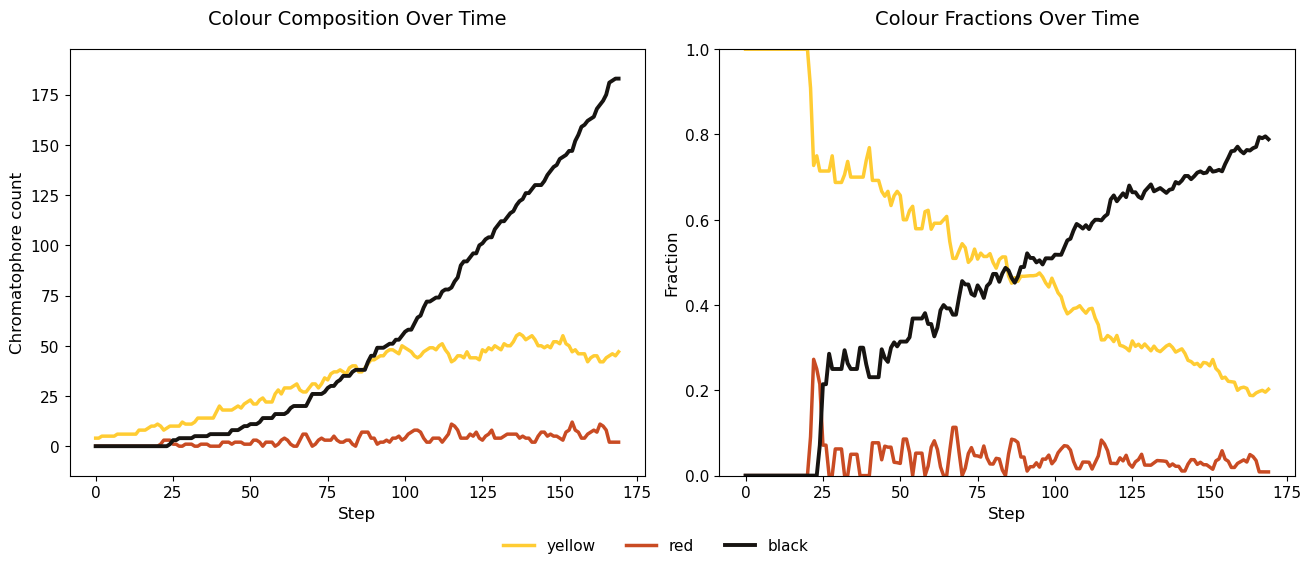

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig3_color_composition_over_time.png
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/metrics_over_time.csv


In [25]:
# %% Cell 8: Fig3 color composition over time
fig3_path = REPORT_DIR / "Fig3_color_composition_over_time.png"
metrics_csv_path = REPORT_DIR / "metrics_over_time.csv"
figsize = (13.0, 5.2)
dpi = 220

metrics_df = timeline_to_dataframe(timeline)
metrics_df.to_csv(metrics_csv_path, index=False)

line_colors = {"yellow": "#ffcc33", "red": "#c94b23", "black": "#171411"}
line_widths = {"yellow": 2.5, "red": 2.5, "black": 2.8}

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
axes[0].plot(metrics_df["step"], metrics_df["yellow_count"], color=line_colors["yellow"], linewidth=line_widths["yellow"], label="yellow")
axes[0].plot(metrics_df["step"], metrics_df["red_count"], color=line_colors["red"], linewidth=line_widths["red"], label="red")
axes[0].plot(metrics_df["step"], metrics_df["black_count"], color=line_colors["black"], linewidth=line_widths["black"], label="black")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Chromatophore count")
axes[0].set_title("Colour Composition Over Time", pad=18)
axes[0].margins(y=0.08)

fraction_df = metrics_df[["yellow_count", "red_count", "black_count"]].div(metrics_df["pigment_count"].replace(0, np.nan), axis=0).fillna(0.0)
axes[1].plot(metrics_df["step"], fraction_df["yellow_count"], color=line_colors["yellow"], linewidth=line_widths["yellow"], label="yellow")
axes[1].plot(metrics_df["step"], fraction_df["red_count"], color=line_colors["red"], linewidth=line_widths["red"], label="red")
axes[1].plot(metrics_df["step"], fraction_df["black_count"], color=line_colors["black"], linewidth=line_widths["black"], label="black")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Fraction")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("Colour Fractions Over Time", pad=18)
axes[1].margins(y=0.05)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.08))
fig.savefig(fig3_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig3_path)
print(metrics_csv_path)


In [ ]:
# %% Cell 9: Fig4 parameter heatmap
fig4_path = REPORT_DIR / "Fig4_parameter_phase_heatmap.png"
parameter_scan_csv_path = REPORT_DIR / "parameter_scan.csv"
figsize = (13.4, 5.6)
dpi = 220

absolute_min_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
target_gap_values = [3.0, 4.0, 5.0, 6.0, 7.0]
n_replicates = 3
replicate_seeds = [params["seed"] + 10 * i for i in range(n_replicates)]

scan_df = scan_parameter_landscape(
    params,
    absolute_min_distance_values=absolute_min_values,
    target_gap_values=target_gap_values,
    seeds=replicate_seeds,
)
scan_df.to_csv(parameter_scan_csv_path, index=False)

cv_grid = (
    scan_df.groupby(["target_gap_to_black", "absolute_min_distance"])["final_cv_nnd"]
    .mean()
    .unstack()
    .reindex(index=target_gap_values, columns=absolute_min_values)
)
order_grid = (
    scan_df.groupby(["target_gap_to_black", "absolute_min_distance"])["order_score"]
    .mean()
    .unstack()
    .reindex(index=target_gap_values, columns=absolute_min_values)
)

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
image1 = axes[0].imshow(cv_grid.to_numpy(), origin="lower", aspect="auto", cmap="magma_r")
axes[0].set_title("Mean Final CV_NND")
axes[0].set_xlabel("absolute_min_distance")
axes[0].set_ylabel("target_gap_to_black")
axes[0].set_xticks(range(len(absolute_min_values)), [f"{value:.1f}" for value in absolute_min_values])
axes[0].set_yticks(range(len(target_gap_values)), [f"{value:.1f}" for value in target_gap_values])
cbar1 = fig.colorbar(image1, ax=axes[0], shrink=0.92)
cbar1.set_label("CV_NND")

image2 = axes[1].imshow(order_grid.to_numpy(), origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("Mean Order Score")
axes[1].set_xlabel("absolute_min_distance")
axes[1].set_ylabel("target_gap_to_black")
axes[1].set_xticks(range(len(absolute_min_values)), [f"{value:.1f}" for value in absolute_min_values])
axes[1].set_yticks(range(len(target_gap_values)), [f"{value:.1f}" for value in target_gap_values])
cbar2 = fig.colorbar(image2, ax=axes[1], shrink=0.92)
cbar2.set_label("Order score")

fig.suptitle("Local-rule Parameter Landscape of Spacing Order", y=1.02, fontsize=17, fontweight="bold")
fig.savefig(fig4_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig4_path)
print(parameter_scan_csv_path)


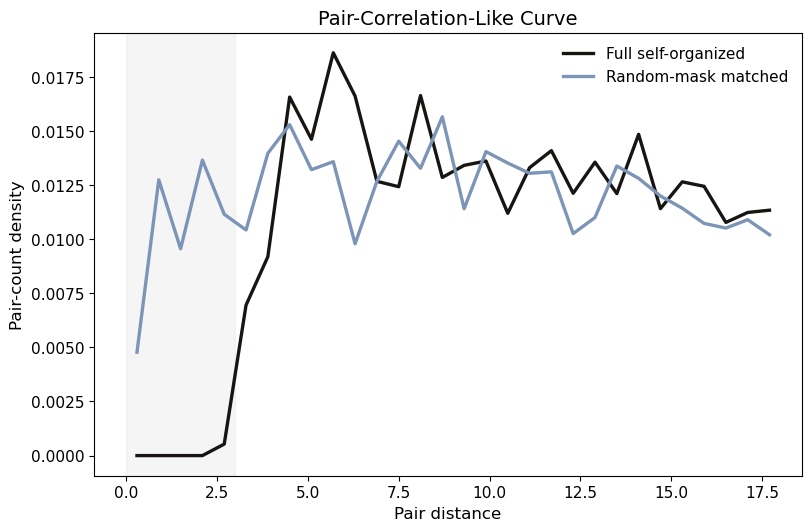

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig5_pair_correlation.png


In [27]:
# %% Cell 10: Fig5 pair correlation
fig5_path = REPORT_DIR / "Fig5_pair_correlation.png"
figsize = (8.0, 5.2)
dpi = 220
r_max = 18.0
bins = np.linspace(0.0, r_max, 31)

self_centers, self_density = pair_correlation_like(pigment_points(final_frame), bins=bins)
mask_centers, mask_density = pair_correlation_like(pigment_points(random_mask_result["final_frame"]), bins=bins)

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
ax.plot(self_centers, self_density, color=MODE_COLORS["self"], linewidth=2.4, label=MODE_LABELS["self"])
ax.plot(mask_centers, mask_density, color=MODE_COLORS["random_mask"], linewidth=2.4, label=MODE_LABELS["random_mask"])
ax.axvspan(0.0, 3.0, color="#d9d9d9", alpha=0.25)
ax.set_xlabel("Pair distance")
ax.set_ylabel("Pair-count density")
ax.set_title("Pair-Correlation-Like Curve")
ax.legend(frameon=False)
fig.savefig(fig5_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig5_path)


In [42]:
# %% Cell 11: Ablation runs
ablation_csv_path = REPORT_DIR / "ablation_summary.csv"

full_self_result = {
    "mode": "self",
    "seed": params["seed"],
    "timeline": timeline,
    "final_step": final_step,
    "final_frame": final_frame,
    "birth_rate_scale": 1.0,
    "switches": {
        "use_repulsion": True,
        "use_gap_birth": True,
        "use_growth_displacement": True,
    },
    "params": params,
}
no_repulsion_result = run_ablation(
    params,
    mode="no_repulsion",
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)
no_gap_birth_result = run_ablation(
    params,
    mode="no_gap_birth",
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)
no_growth_displacement_result = run_ablation(
    params,
    mode="no_growth_displacement",
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)

ablation_results = [
    full_self_result,
    no_repulsion_result,
    no_gap_birth_result,
    no_growth_displacement_result,
    random_dev_result,
    random_mask_result,
]

ablation_summary_df = pd.DataFrame([summarize_result(result) for result in ablation_results])
ablation_summary_df.to_csv(ablation_csv_path, index=False)

print(ablation_summary_df[["model", "N", "CV_NND", "yellow_count", "red_count", "black_count"]])
print(ablation_csv_path)

ablation_summary_df


                        model    N    CV_NND  yellow_count  red_count  \
0                        self  185  0.169153            55          2   
1                no_repulsion  183  0.451245            51          3   
2                no_gap_birth  158  0.195394            49          5   
3      no_growth_displacement  159  0.221441            37         10   
4  random_development_matched  188  0.625262            51          6   
5                 random_mask  185  0.493751            55          2   

   black_count  
0          128  
1          129  
2          104  
3          112  
4          131  
5          128  
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/ablation_summary.csv


,model,seed,N,mean_NND,std_NND,CV_NND,yellow_count,red_count,black_count,yellow_fraction,red_fraction,black_fraction,use_repulsion,use_gap_birth,use_growth_displacement,calibrated_birth_rate
0,self,7,185,4.317550,0.730327,0.169153,55,2,128,0.297297,0.010811,0.691892,True,True,True,1.000000
1,no_repulsion,7,183,2.834065,1.278857,0.451245,51,3,129,0.278689,0.016393,0.704918,False,True,True,0.003125
2,no_gap_birth,7,158,4.359511,0.851822,0.195394,49,5,104,0.310127,0.031646,0.658228,True,False,True,0.102500
3,no_growth_displacement,7,159,3.825517,0.847126,0.221441,37,10,112,0.232704,0.062893,0.704403,True,True,False,1.000000
4,random_development_matched,7,188,2.623428,1.640331,0.625262,51,6,131,0.271277,0.031915,0.696809,False,False,True,0.002000
5,random_mask,407,185,3.156232,1.558393,0.493751,55,2,128,0.297297,0.010811,0.691892,False,False,False,NaN


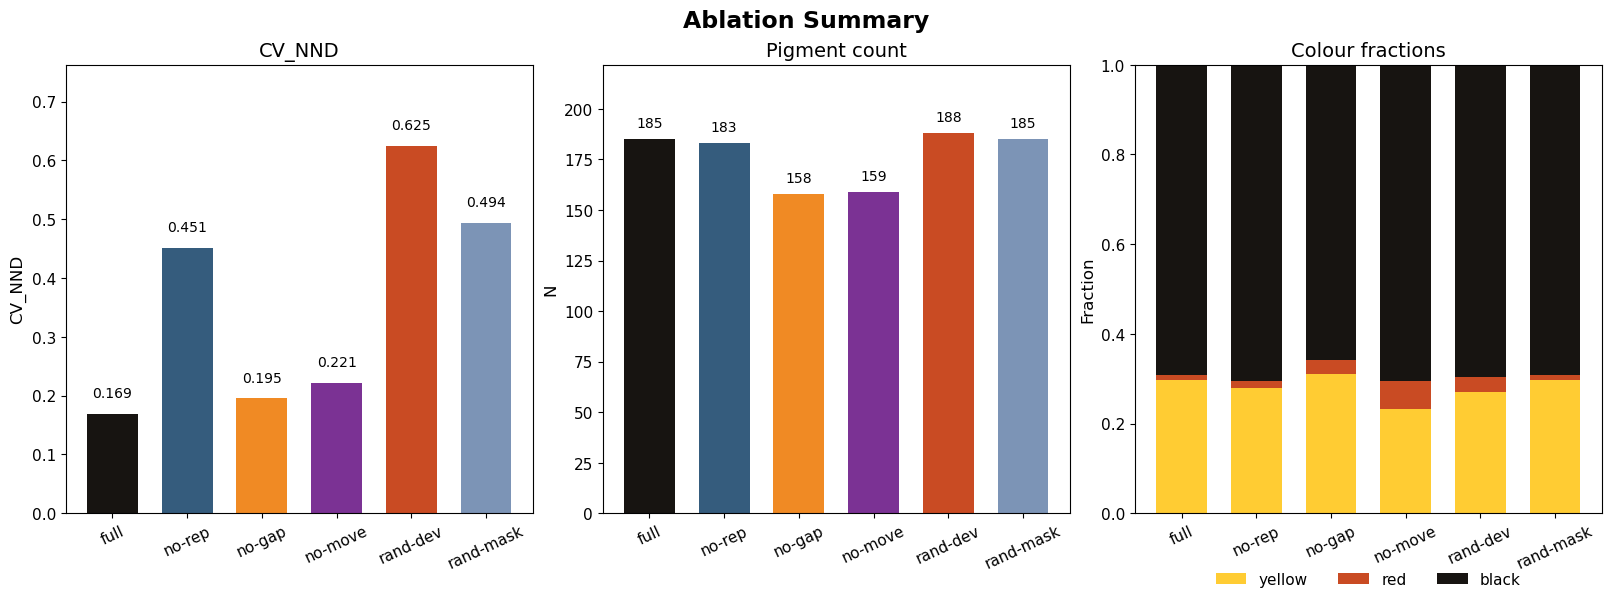

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig6_ablation_summary.png


In [43]:
# %% Cell 12: Fig6 ablation summary
fig6_path = REPORT_DIR / "Fig6_ablation_summary.png"
figsize = (16.0, 5.6)
dpi = 220

order = ["self", "no_repulsion", "no_gap_birth", "no_growth_displacement", "random_development_matched", "random_mask"]
labels = ["full", "no-rep", "no-gap", "no-move", "rand-dev", "rand-mask"]
colors = [MODE_COLORS[key] for key in order]
ablation_summary_df = pd.read_csv(ablation_csv_path)
summary_indexed = ablation_summary_df.set_index("model").loc[order]

fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)
cv_values = summary_indexed["CV_NND"].to_numpy()
axes[0].bar(labels, cv_values, color=colors, width=0.68)
axes[0].set_title("CV_NND")
axes[0].set_ylabel("CV_NND")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylim(0.0, max(cv_values) * 1.22)
for idx, value in enumerate(cv_values):
    axes[0].text(idx, value + 0.03 * axes[0].get_ylim()[1], f"{value:.3f}", ha="center", va="bottom", fontsize=10)

n_values = summary_indexed["N"].to_numpy()
axes[1].bar(labels, n_values, color=colors, width=0.68)
axes[1].set_title("Pigment count")
axes[1].set_ylabel("N")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylim(0.0, max(n_values) * 1.18)
for idx, value in enumerate(n_values):
    axes[1].text(idx, value + 0.02 * axes[1].get_ylim()[1], f"{value:.0f}", ha="center", va="bottom", fontsize=10)

bottoms = np.zeros(len(order))
for col, color, label in [
    ("yellow_fraction", "#ffcc33", "yellow"),
    ("red_fraction", "#c94b23", "red"),
    ("black_fraction", "#171411", "black"),
]:
    axes[2].bar(labels, summary_indexed[col], bottom=bottoms, color=color, width=0.68, label=label)
    bottoms += summary_indexed[col].to_numpy()
axes[2].set_ylim(0.0, 1.0)
axes[2].set_title("Colour fractions")
axes[2].set_ylabel("Fraction")
axes[2].tick_params(axis="x", rotation=25)
axes[2].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

fig.suptitle("Ablation Summary", y=1.05, fontsize=17, fontweight="bold")
fig.savefig(fig6_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig6_path)


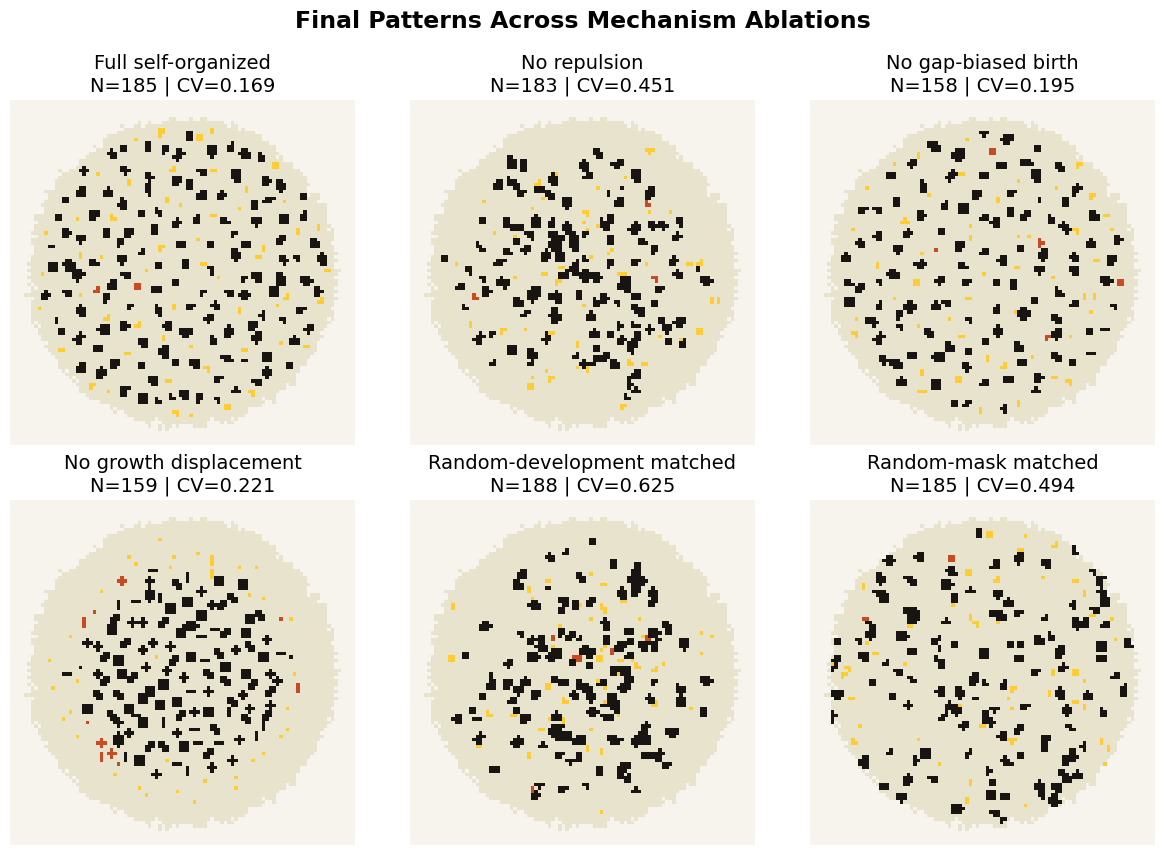

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig7_ablation_final_patterns.png


In [45]:
# %% Cell 13: Fig7 ablation final patterns
fig7_path = REPORT_DIR / "Fig7_ablation_final_patterns.png"
figsize = (12.0, 8.0)
dpi = 220

pattern_results = [
    full_self_result,
    no_repulsion_result,
    no_gap_birth_result,
    no_growth_displacement_result,
    random_dev_result,
    random_mask_result,
]

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)
priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}

fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
for ax, result in zip(axes.flat, pattern_results):
    frame = result["final_frame"]
    state_grid = frame.skin.copy()
    score_grid = np.full(frame.skin.shape, -np.inf, dtype=float)
    grid_size = frame.skin.shape[0]
    for pigment in frame.pigments:
        stage = pigment.stage(params)
        major, minor = pigment_display_size(pigment, params)
        half_h = max(1, int(math.ceil(major * 0.75)))
        half_w = max(1, int(math.ceil(major * 0.75)))
        rr_center = pigment.pos[0]
        cc_center = pigment.pos[1]
        angle = math.radians(pigment.angle)
        cos_a = math.cos(angle)
        sin_a = math.sin(angle)
        rows = []
        cols = []
        for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
            if rr < 0 or rr >= grid_size:
                continue
            for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
                if cc < 0 or cc >= grid_size:
                    continue
                dy = rr - rr_center
                dx = cc - cc_center
                x_rot = cos_a * dx + sin_a * dy
                y_rot = -sin_a * dx + cos_a * dy
                value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
                if value <= 1.0:
                    rows.append(rr)
                    cols.append(cc)
        if not rows:
            rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
            cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]
        rows = np.asarray(rows, dtype=int)
        cols = np.asarray(cols, dtype=int)
        dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
        local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age
        for rr, cc, score in zip(rows, cols, local_score):
            if frame.skin[rr, cc] != SKIN:
                continue
            if score > score_grid[rr, cc]:
                state_grid[rr, cc] = stage
                score_grid[rr, cc] = score
    ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{MODE_LABELS[result['mode']]}\nN={frame.pigment_count} | CV={frame.nnd_cv:.3f}", pad=7)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Final Patterns Across Mechanism Ablations", y=1.05, fontsize=17, fontweight="bold")
fig.savefig(fig7_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig7_path)


In [ ]:
# # %% Cell 14: Export markdown summary
# summary_md_path = REPORT_DIR / "model_math_summary.md"

# self_row = summary_df.set_index("model").loc["self"]
# rand_row = summary_df.set_index("model").loc["random_development_matched"]
# mask_row = summary_df.set_index("model").loc["random_mask"]
# no_rep_row = ablation_summary_df.set_index("model").loc["no_repulsion"]
# no_gap_row = ablation_summary_df.set_index("model").loc["no_gap_birth"]
# no_move_row = ablation_summary_df.set_index("model").loc["no_growth_displacement"]

# summary_text = f"""# 模型数学摘要

# ## 1. 状态变量

# 二维格点元胞自动机状态记为 $S_{{ij}}(t) \in \{{0,1,2,3,4\}}$：

# - 0：空白区域
# - 1：普通皮肤细胞
# - 2：黄色新生色素细胞
# - 3：红色过渡态色素细胞
# - 4：黑色成熟色素细胞

# ## 2. 皮肤生长与出生逻辑

# 皮肤从中心小区域向外扩张，出生概率可概括为：

# $$
# P_{{birth}} = \beta \cdot I(d_{{all}}) \cdot G(d_{{black}}) \cdot B(d_{{boundary}})
# $$

# 其中：

# - $I(d_{{all}})$：短程抑制与最小间距
# - $G(d_{{black}})$：对成熟黑色阵列空隙的偏好
# - $B(d_{{boundary}})$：边界惩罚

# ## 3. 颜色成熟

# - yellow_duration = {params['yellow_duration']}
# - red_duration = {params['red_duration']}

# ## 4. 匹配随机对照

# - self: N = {int(self_row['N'])}, CV_NND = {self_row['CV_NND']:.4f}
# - random-development matched: N = {int(rand_row['N'])}, CV_NND = {rand_row['CV_NND']:.4f}
# - random-mask matched: N = {int(mask_row['N'])}, CV_NND = {mask_row['CV_NND']:.4f}

# ## 5. Ablation

# - no_repulsion: N = {int(no_rep_row['N'])}, CV_NND = {no_rep_row['CV_NND']:.4f}
# - no_gap_birth: N = {int(no_gap_row['N'])}, CV_NND = {no_gap_row['CV_NND']:.4f}
# - no_growth_displacement: N = {int(no_move_row['N'])}, CV_NND = {no_move_row['CV_NND']:.4f}

# ## 6. 图解释

# - Fig1：self 与 matched random-development 的发育切片比较
# - Fig2：NND 分布与 CV_NND 对比
# - Fig3：yellow / red / black 随时间变化
# - Fig4：局部规则参数景观
# - Fig5：短距离 pair-density dip
# - Fig6/Fig7：ablation 对空间秩序的影响
# """

# summary_md_path.write_text(summary_text, encoding="utf-8")
# print(summary_md_path)
